In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [3]:
# function transformer 
# power transformer 
# column transformer


In [4]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

In [13]:
transform = FunctionTransformer(np.log) 
# np.log1p(np.array([-0.1,2,3,4, 120]))

array([-0.10536052,  1.09861229,  1.38629436,  1.60943791,  4.79579055])

In [15]:
df = pd.read_csv("../../Data/CarPrice_Assignment.csv")

In [17]:
import seaborn as sns

<Axes: xlabel='price', ylabel='Density'>

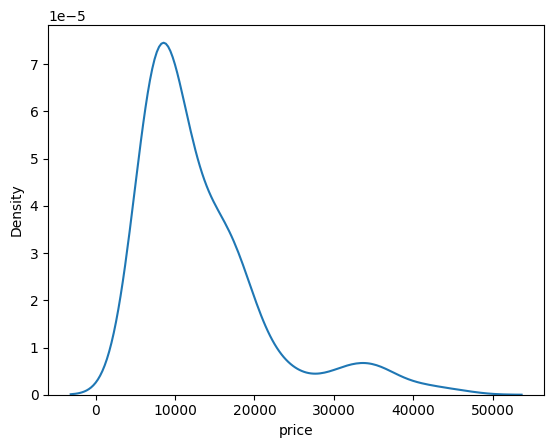

In [23]:
sns.kdeplot(df['price'])


<Axes: ylabel='Density'>

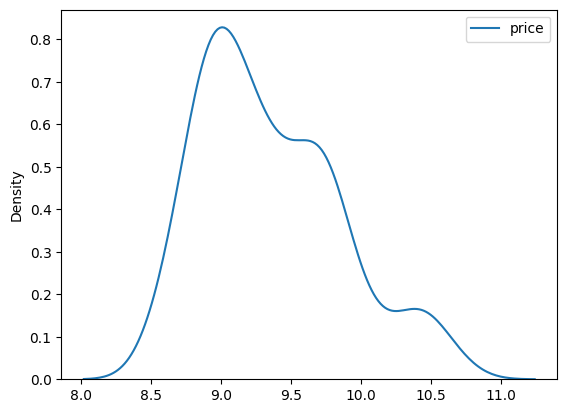

In [24]:
sns.kdeplot(data)

In [19]:
transform = FunctionTransformer(np.log1p)

In [21]:
data = transform.fit_transform(df[['price']])

In [ ]:
# transform.transform()
transform.fit()


In [32]:
T = PowerTransformer(method='box-cox')

In [33]:
arr = T.fit_transform(df[['price']])

<Axes: ylabel='Density'>

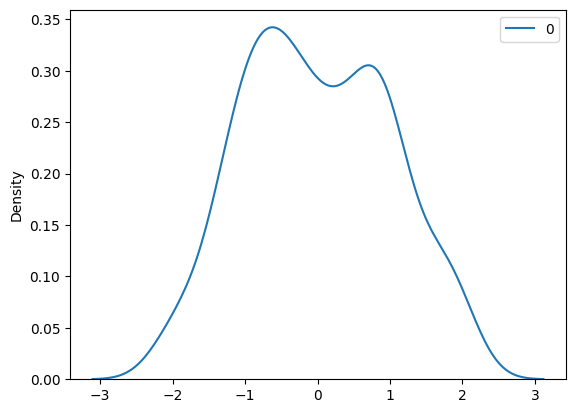

In [34]:
sns.kdeplot(arr)

In [35]:
np.mean(arr), np.std(arr)

(np.float64(-7.674728061740496e-14), np.float64(1.0))

In [36]:
# list of tuples 
# [(name, method name, col)]
from sklearn.compose import ColumnTransformer


Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem'],
      dtype='str')

In [60]:
transform = ColumnTransformer(
    transformers=[
        ('S', StandardScaler(), df.select_dtypes('number').columns[:-1]),
        ('ohe', OneHotEncoder(sparse_output=False, drop='first'), df.select_dtypes('string').columns[1:])
    ],
    remainder='passthrough'
)

In [63]:
arr = transform.fit_transform(df)

In [62]:
transform.get_feature_names_out()

array(['S__car_ID', 'S__symboling', 'S__wheelbase', 'S__carlength',
       'S__carwidth', 'S__carheight', 'S__curbweight', 'S__enginesize',
       'S__boreratio', 'S__stroke', 'S__compressionratio',
       'S__horsepower', 'S__peakrpm', 'S__citympg', 'S__highwaympg',
       'ohe__fueltype_gas', 'ohe__aspiration_turbo',
       'ohe__doornumber_two', 'ohe__carbody_hardtop',
       'ohe__carbody_hatchback', 'ohe__carbody_sedan',
       'ohe__carbody_wagon', 'ohe__drivewheel_fwd', 'ohe__drivewheel_rwd',
       'ohe__enginelocation_rear', 'ohe__enginetype_dohcv',
       'ohe__enginetype_l', 'ohe__enginetype_ohc', 'ohe__enginetype_ohcf',
       'ohe__enginetype_ohcv', 'ohe__enginetype_rotor',
       'ohe__cylindernumber_five', 'ohe__cylindernumber_four',
       'ohe__cylindernumber_six', 'ohe__cylindernumber_three',
       'ohe__cylindernumber_twelve', 'ohe__cylindernumber_two',
       'ohe__fuelsystem_2bbl', 'ohe__fuelsystem_4bbl',
       'ohe__fuelsystem_idi', 'ohe__fuelsystem_mfi',
      

In [48]:
# df['symboling'].unique()

In [67]:
arr[:,:-1]

array([[-1.7236222864675912, 1.7434704321932961, -1.6907718018201774,
        ..., 0.0, 0.0, 'alfa-romero giulia'],
       [-1.7067240287571246, 1.7434704321932961, -1.6907718018201774,
        ..., 0.0, 0.0, 'alfa-romero stelvio'],
       [-1.689825771046658, 0.13350899705984703, -0.7085958764076113,
        ..., 0.0, 0.0, 'alfa-romero Quadrifoglio'],
       ...,
       [1.689825771046658, -1.476452438073602, 1.7218733627489047, ...,
        0.0, 0.0, 'volvo 244dl'],
       [1.7067240287571246, -1.476452438073602, 1.7218733627489047, ...,
        0.0, 0.0, 'volvo 246'],
       [1.7236222864675912, -1.476452438073602, 1.7218733627489047, ...,
        0.0, 0.0, 'volvo 264gl']], shape=(205, 45), dtype=object)

In [71]:
y = arr[:, -1]
X = arr[:, :-2]


In [72]:
y.shape, X.shape

((205,), (205, 44))

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
from sklearn.linear_model import *
from sklearn.metrics import r2_score

In [77]:
def check_output(cls):
    obj = cls
    obj.fit(X_train, y_train)
    y_pred = obj.predict(X_test)
    return (r2_score(y_test, y_pred))

In [79]:
check_output(LinearRegression())

0.9005298423323502

In [80]:
check_output(Lasso())

0.8983765072940861

In [81]:
check_output(Ridge())

0.8906683726819045